# Modelo predictivo de PM2.5

Este notebook desarrolla un modelo de predicción diaria (a un día vista) de **PM2.5** en las estaciones de calidad del aire de Madrid.

El diseño parte de un **análisis exploratorio propio de PM2.5** y de decisiones metodológicas justificadas de forma independiente para este contaminante en concreto. Las decisiones clave, y su motivo, son:

| Decisión | Motivo |
|---|---|
| Target transformado con `log1p` | PM2.5 presenta una distribución muy asimétrica (asimetría ≈ 2.4); entrenar sobre la escala log reduce el peso desproporcionado de los picos extremos en la función de pérdida |
| Meteorología asignada por **estación más cercana** (distancias de `enriched.dim_estaciones_aire`, calculada variable a variable) | Captura mejor las diferencias microclimáticas entre zonas de la ciudad que un promedio agregado; el emparejamiento por variable evita perder cobertura cuando la estación meteo más cercana no reporta alguna magnitud concreta |
| Se incluyen `LATITUD_G`, `LONGITUD_G` y `ALTITUD` como features del modelo | Permite que el modelo capture patrones espaciales fijos (p. ej. zonas con peor dispersión por altitud o cercanía a vías principales) más allá de lo que ya aporta la meteorología asignada |
| Se añaden `viento_velocidad`, `viento_racha` y `presion_*` con prioridad explícita | Son las variables con mayor correlación empírica con PM2.5 (dispersión atmosférica y episodios anticiclónicos) |
| Se incluye lag de **PM10** y de **NO2** de la propia estación (no promedio ciudad) | NO2 y PM10 se miden en la misma red de estaciones que PM2.5 (a diferencia del clima), así que se usa el valor real medido en cada estación; verificado por correlación propia: PM10 correlaciona 0.80 con PM2.5 (subconjunto físico), NO2 correlaciona 0.52; O3 se descarta (correlación débil, −0.28, y baja cobertura de estaciones) |
| Se añade un **"lag espacial"**: PM2.5 medio del resto de la ciudad el día anterior | La correlación entre el valor de una estación y la media de la ciudad es muy alta (0.89), lo que sugiere episodios regionales sincronizados (p. ej. calima) que una sola estación no captura por sí sola |
| Se añaden medias y desviaciones móviles (rolling 3 y 7 días) | Suavizan el ruido diario y capturan el régimen de contaminación reciente, más allá de un único valor puntual (lag) |
| `estacion` tratada como variable **categórica real** (no entera ordinal) | Evita que el modelo interprete una relación de orden inexistente entre los códigos de estación |
| Búsqueda de hiperparámetros con `early_stopping_rounds` sobre un conjunto de validación, en vez de grid search exhaustivo | Más eficiente computacionalmente y evita sobreajustar el número de árboles a mano |
| Se documenta explícitamente el evento de calima (15-mar-2022) como límite conocido del modelo | Es una variable regional (polvo sahariano) no capturada por meteorología local ni por contaminantes; el modelo previsiblemente fallará en detectarla con antelación |


In [1]:
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

MAGNITUD_PM25 = 9
MAGNITUD_PM10 = 10
MAGNITUD_NO2 = 8

RANDOM_STATE = 42


In [2]:
# ============================================================
# LOCALIZACIÓN DEL PROYECTO Y CONEXIÓN A DUCKDB
# (se trabaja directamente sobre los ficheros Parquet de data/enriched,
#  sin depender de que exista una base de datos TFM.duckdb ya construida)
# ============================================================

# Si la detección automática no encuentra la carpeta del proyecto (por ejemplo
# porque el notebook se ejecuta desde un directorio de trabajo distinto al
# esperado), se puede indicar la ruta manualmente aquí. Dejar en None para
# que se busque automáticamente subiendo desde la carpeta actual.
PROJECT_ROOT_OVERRIDE = None  # p. ej.: r"C:\Users\tuusuario\TFM" o "/home/usuario/TFM"

if PROJECT_ROOT_OVERRIDE is not None:
    ROOT = Path(PROJECT_ROOT_OVERRIDE)
    if not (ROOT / "data" / "enriched").exists():
        raise FileNotFoundError(
            f"PROJECT_ROOT_OVERRIDE no contiene data/enriched: {ROOT}"
        )
else:
    _cwd_inicial = Path.cwd()
    ROOT = _cwd_inicial

    while not (ROOT / "data" / "enriched").exists():
        if ROOT.parent == ROOT:
            print("No se ha encontrado 'data/enriched' subiendo desde:", _cwd_inicial)
            print("Carpetas comprobadas hasta llegar a la raíz del sistema.")
            print()
            print("Posibles causas:")
            print("  1) VS Code no tiene abierta la carpeta del repo TFM como workspace")
            print("     (File > Open Folder... y selecciona la carpeta raíz del repo).")
            print("  2) El directorio de trabajo del kernel no es el esperado. Revisa:")
            print("     Settings > busca 'jupyter.notebookFileRoot'.")
            print("  3) La carpeta data/enriched no existe en tu copia local del repo.")
            print()
            print("Alternativa rápida: define PROJECT_ROOT_OVERRIDE arriba con la ruta")
            print("absoluta a la carpeta TFM y vuelve a ejecutar esta celda.")
            raise FileNotFoundError(
                "No se ha encontrado la carpeta data/enriched. "
                "Ver mensaje de diagnóstico impreso arriba."
            )
        ROOT = ROOT.parent

CALIDAD_AIRE_PATH = ROOT / "data" / "enriched" / "fact" / "calidad_aire_final.parquet"
METEO_PATH = ROOT / "data" / "enriched" / "fact" / "meteo_final.parquet"

assert CALIDAD_AIRE_PATH.exists(), f"No se encuentra: {CALIDAD_AIRE_PATH}"
assert METEO_PATH.exists(), f"No se encuentra: {METEO_PATH}"

# Conexión DuckDB "en memoria": no requiere ningún archivo .duckdb previo,
# se usa únicamente como motor SQL para leer los Parquet directamente.
con = duckdb.connect(database=":memory:")

print("Directorio de trabajo detectado:", Path.cwd())
print("Raíz del proyecto:", ROOT)
print("Calidad de aire:", CALIDAD_AIRE_PATH)
print("Meteorología:", METEO_PATH)
print("Conexión a DuckDB (en memoria) realizada correctamente.")


Directorio de trabajo detectado: /home/claude/TFM/src/models/PM25_propio
Raíz del proyecto: /home/claude/TFM
Calidad de aire: /home/claude/TFM/data/enriched/fact/calidad_aire_final.parquet
Meteorología: /home/claude/TFM/data/enriched/fact/meteo_final.parquet
Conexión a DuckDB (en memoria) realizada correctamente.


## 1. Análisis exploratorio propio de PM2.5

Antes de decidir qué variables usar, se analiza la distribución del contaminante, la presencia de valores extremos y su naturaleza (¿ruido o señal real?), y la correlación empírica con meteorología y otros contaminantes. Estas decisiones son las que guían el diseño del dataset de modelado.


In [3]:
# ============================================================
# CARGA DE PM2.5
# ============================================================

pm25 = con.execute(
    """
    SELECT fecha, estacion, uom_value AS pm25, es_laborable_madrid_ciudad
    FROM read_parquet(?)
    WHERE magnitud = ?
    ORDER BY estacion, fecha
    """,
    [str(CALIDAD_AIRE_PATH), MAGNITUD_PM25]
).fetchdf()

pm25["fecha"] = pd.to_datetime(pm25["fecha"])

print("Shape:", pm25.shape)
print("Estaciones:", sorted(pm25['estacion'].unique()))
print("Periodo:", pm25['fecha'].min(), "→", pm25['fecha'].max())
print("Nulos:", pm25['pm25'].isna().sum())
print("Duplicados estacion-fecha:", pm25.duplicated(['estacion','fecha']).sum())


Shape: (14616, 4)
Estaciones: [np.int64(8), np.int64(24), np.int64(38), np.int64(47), np.int64(48), np.int64(50), np.int64(56), np.int64(57)]
Periodo: 2020-01-01 00:00:00 → 2024-12-31 00:00:00
Nulos: 0
Duplicados estacion-fecha: 0


count    14616.000000
mean         9.380798
std          6.181747
min          1.000000
25%          5.166667
50%          8.125000
75%         11.837500
max         84.291667
Name: pm25, dtype: float64

Asimetría (skew): 2.3946947739806053
Curtosis: 12.337754311238093


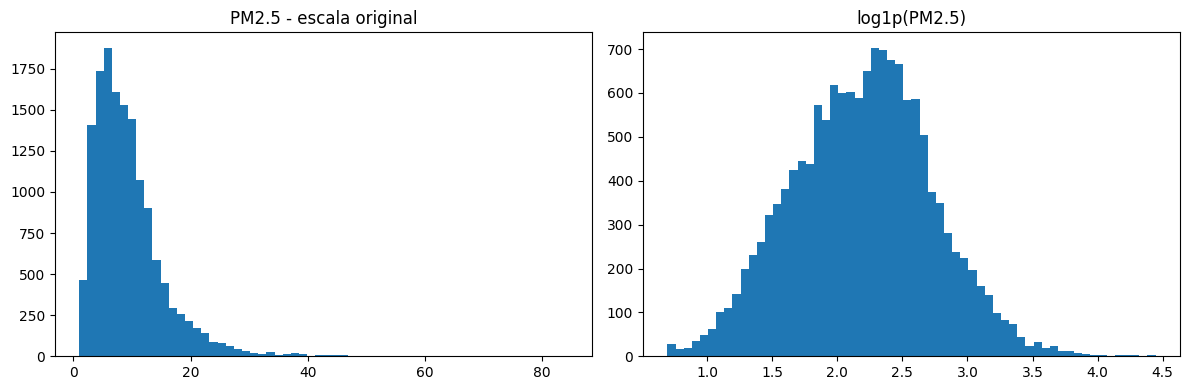

In [4]:
# ============================================================
# DISTRIBUCIÓN DEL TARGET
# ============================================================

print(pm25['pm25'].describe())
print("\nAsimetría (skew):", pm25['pm25'].skew())
print("Curtosis:", pm25['pm25'].kurtosis())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pm25['pm25'], bins=60)
axes[0].set_title("PM2.5 - escala original")
axes[1].hist(np.log1p(pm25['pm25']), bins=60)
axes[1].set_title("log1p(PM2.5)")
plt.tight_layout()
plt.show()


La distribución en escala original está claramente sesgada a la derecha, con una cola larga de valores altos. La transformación `log1p` la aproxima mucho más a una distribución simétrica, lo que favorece el entrenamiento del modelo (los errores en la escala log penalizan de forma proporcional, no absoluta, evitando que unos pocos episodios extremos dominen la función de pérdida).


In [5]:
# ============================================================
# EPISODIO EXTREMO: ¿RUIDO O SEÑAL REAL?
# ============================================================

top_dias = (
    pm25.groupby("fecha")["pm25"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)
print("Días con mayor PM2.5 medio (todas las estaciones):")
print(top_dias)


Días con mayor PM2.5 medio (todas las estaciones):
fecha
2022-03-15    63.223958
2021-01-16    56.369827
2021-01-14    43.544695
2021-01-15    42.069588
2021-01-17    40.144136
Name: pm25, dtype: float64


In [6]:
# Se comprueba si el pico principal afecta a todas las estaciones a la vez
dia_pico = top_dias.index[0]

detalle_pico = pm25[pm25["fecha"] == dia_pico].sort_values("pm25", ascending=False)
print(f"Detalle del {dia_pico.date()} por estación:")
display(detalle_pico)


Detalle del 2022-03-15 por estación:


,fecha,estacion,pm25,es_laborable_madrid_ciudad
2631,2022-03-15,24,84.291667,True
6285,2022-03-15,47,79.166667,True
9939,2022-03-15,50,77.041667,True
13593,2022-03-15,57,69.708333,True
804,2022-03-15,8,66.208333,True
8112,2022-03-15,48,50.708333,True
4458,2022-03-15,38,39.333333,True
11766,2022-03-15,56,39.333333,True


El pico afecta simultáneamente a **todas** las estaciones de la ciudad, lo cual es la firma característica de una **intrusión de polvo sahariano (calima)**, un fenómeno meteorológico regional documentado y frecuente en Madrid en marzo. No se trata de un error de sensor ni de un evento local de tráfico, por lo que **no se elimina** como outlier: es señal real, aunque previsiblemente difícil de predecir con la información disponible en este dataset (no se dispone de datos de concentración de polvo atmosférico ni de trayectorias de masas de aire). Se documenta como limitación conocida del modelo.


## 2. Meteorología: estación más cercana por variable

A cada estación de calidad del aire se le asigna la estación meteorológica AEMET **geográficamente más cercana**, usando las distancias ya calculadas (fórmula Haversine) en `enriched.dim_estaciones_aire` — la misma tabla y el mismo criterio de distancia que usa el resto del proyecto. Como no todas las estaciones meteorológicas reportan todas las variables, el emparejamiento se calcula de forma **independiente para cada variable** (temperatura, viento, presión, etc.), seleccionando en cada caso la estación más cercana que sí disponga de esa variable concreta.


In [7]:
# ============================================================
# METADATA DE ESTACIONES (dim_estaciones_aire, ya con distancias a meteo)
# ============================================================

DIM_ESTACIONES_PATH = ROOT / "data" / "enriched" / "dims" / "dim_estaciones_aire.parquet"

assert DIM_ESTACIONES_PATH.exists(), f"No se encuentra: {DIM_ESTACIONES_PATH}"

estaciones_aire = con.execute(
    """
    SELECT *
    FROM read_parquet(?)
    """,
    [str(DIM_ESTACIONES_PATH)]
).fetchdf()

print("Shape dim_estaciones_aire:", estaciones_aire.shape)
display(estaciones_aire[["ESTACION", "NOMBRE", "LATITUD_G", "LONGITUD_G", "ALTITUD", "TIPO_ESTACION"]].head())


Shape dim_estaciones_aire: (25, 11)


,ESTACION,NOMBRE,LATITUD_G,LONGITUD_G,ALTITUD,TIPO_ESTACION
0,8,ESCUELAS AGUIRRE,40.42167,-3.68222,672,TRAFICO
1,16,ARTURO SORIA,40.44000,-3.63917,698,FONDO
2,17,VILLAVERDE,40.34694,-3.70500,593,FONDO
3,18,FAROLILLO,40.39472,-3.73194,625,FONDO
4,24,CASA DE CAMPO,40.42000,-3.74917,645,FONDO


In [8]:
# ============================================================
# DISTANCIAS A ESTACIONES METEO (desde dim_estaciones_aire.distancias_meteo)
# ============================================================

con.register("estaciones_aire_tmp", estaciones_aire)

distancias = con.execute(
    """
    SELECT
        a.ESTACION AS estacion,
        kv.key AS estacion_meteo,
        kv.value AS distancia_km
    FROM estaciones_aire_tmp a,
         UNNEST(map_entries(a.distancias_meteo)) AS t(kv)
    ORDER BY estacion, distancia_km
    """
).fetchdf()

# Nos quedamos solo con las estaciones que miden PM2.5
distancias = distancias[distancias["estacion"].isin(pm25["estacion"].unique())].copy()

print("Estación meteo más cercana por estación de aire (PM2.5):")
display(
    distancias
    .sort_values(["estacion", "distancia_km"])
    .groupby("estacion")
    .first()
    .reset_index()
)


Estación meteo más cercana por estación de aire (PM2.5):


,estacion,estacion_meteo,distancia_km
0,8,3195,1.12
1,24,3196,4.10
2,38,3196,1.91
3,47,3195,1.60
4,48,3195,3.22
5,50,3196,3.56
6,56,3195,4.41
7,57,3196,7.27


In [9]:
# ============================================================
# METEOROLOGÍA — VALOR DE LA ESTACIÓN MÁS CERCANA, POR VARIABLE
# (no todas las estaciones meteo reportan todas las variables, así que el
#  emparejamiento se calcula variable a variable, no una única estación
#  "más cercana en general")
# ============================================================

meteo_long = con.execute(
    """
    SELECT fecha, estacion_id AS estacion_meteo, variable, uom_value
    FROM read_parquet(?)
    """,
    [str(METEO_PATH)]
).fetchdf()

meteo_long["fecha"] = pd.to_datetime(meteo_long["fecha"])
meteo_long["estacion_meteo"] = meteo_long["estacion_meteo"].astype(str)

variables_disponibles = (
    meteo_long[["estacion_meteo", "variable"]]
    .drop_duplicates()
)

candidatos = distancias.merge(variables_disponibles, on="estacion_meteo", how="inner")

mapping_meteo_variable = (
    candidatos
    .sort_values(["estacion", "variable", "distancia_km"])
    .groupby(["estacion", "variable"], as_index=False)
    .first()
)

display(mapping_meteo_variable.head(20))


,estacion,variable,estacion_meteo,distancia_km
0,8,direccion_racha_max,3195,1.12
1,8,humedad_max,3195,1.12
2,8,humedad_media,3195,1.12
3,8,humedad_min,3195,1.12
4,8,insolacion,3196,5.11
5,8,precipitacion,3195,1.12
6,8,presion_max,3195,1.12
7,8,presion_min,3195,1.12
8,8,temp_max,3195,1.12
9,8,temp_media,3195,1.12


In [10]:
# ============================================================
# APLICAR EL MAPPING: VALOR METEO DE LA ESTACIÓN MÁS CERCANA, POR VARIABLE
# ============================================================

meteo_asignado = mapping_meteo_variable.merge(
    meteo_long,
    on=["estacion_meteo", "variable"],
    how="left"
)

meteo_por_estacion = (
    meteo_asignado
    .pivot_table(
        index=["estacion", "fecha"],
        columns="variable",
        values="uom_value"
    )
    .reset_index()
)
meteo_por_estacion.columns.name = None

print("Shape:", meteo_por_estacion.shape)
print("\nNulos por variable:")
print(meteo_por_estacion.isna().sum())

display(meteo_por_estacion.head())


Shape: (14616, 15)

Nulos por variable:
estacion               0
fecha                  0
direccion_racha_max    0
humedad_max            0
humedad_media          0
humedad_min            0
insolacion             0
precipitacion          0
presion_max            0
presion_min            0
temp_max               0
temp_media             0
temp_min               0
viento_racha           0
viento_velocidad       0
dtype: int64


,estacion,fecha,direccion_racha_max,humedad_max,humedad_media,humedad_min,insolacion,precipitacion,presion_max,presion_min,temp_max,temp_media,temp_min,viento_racha,viento_velocidad
0,8,2020-01-01,50.0,80.0,65.0,48.0,8.7,0.0,954.2,952.0,11.2,6.6,1.9,3.3,0.3
1,8,2020-01-02,230.0,89.0,77.0,63.0,8.3,0.0,953.7,951.0,10.5,6.0,1.6,3.3,0.6
2,8,2020-01-03,95.0,89.0,83.0,74.0,1.4,0.0,954.8,952.2,6.0,3.8,1.5,5.0,0.6
3,8,2020-01-04,40.0,77.0,58.0,44.0,8.9,0.0,955.9,952.5,11.2,7.0,2.8,9.4,2.5
4,8,2020-01-05,50.0,74.0,53.0,42.0,8.6,0.0,953.3,949.2,10.9,6.2,1.5,5.3,0.8


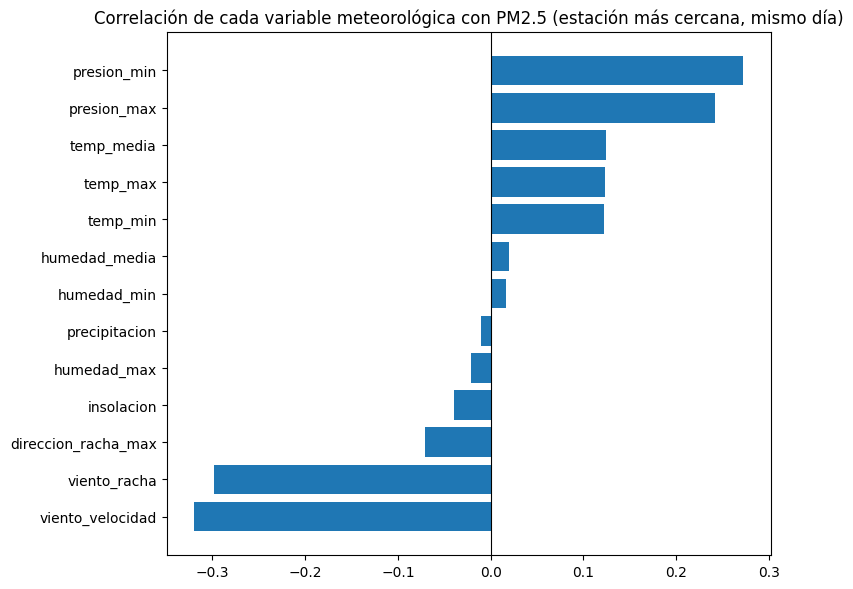

viento_velocidad      -0.319623
viento_racha          -0.298404
direccion_racha_max   -0.070948
insolacion            -0.039096
humedad_max           -0.020997
precipitacion         -0.010439
humedad_min            0.016797
humedad_media          0.019593
temp_min               0.121614
temp_max               0.122960
temp_media             0.124468
presion_max            0.241519
presion_min            0.272102
Name: pm25, dtype: float64


In [11]:
# ============================================================
# CORRELACIÓN EMPÍRICA PM2.5 vs METEOROLOGÍA (ESTACIÓN MÁS CERCANA)
# ============================================================

exploracion = pm25.merge(meteo_por_estacion, on=["estacion", "fecha"], how="left")

cols_meteo = [c for c in meteo_por_estacion.columns if c not in ("estacion", "fecha")]
corr_meteo = exploracion[["pm25"] + cols_meteo].corr()["pm25"].drop("pm25").sort_values()

plt.figure(figsize=(8, 6))
plt.barh(corr_meteo.index, corr_meteo.values)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlación de cada variable meteorológica con PM2.5 (estación más cercana, mismo día)")
plt.tight_layout()
plt.show()

print(corr_meteo)


El viento (velocidad y racha) muestra la correlación negativa más fuerte —coherente con su papel dispersor de partículas— y la presión muestra correlación positiva —coherente con episodios anticiclónicos de aire estancado—. Estas variables se priorizan explícitamente en el modelo, sin descartar el resto de variables meteorológicas disponibles.


## 3. Contaminantes cruzados: selección basada en correlación propia

Se evalúa la correlación de PM2.5 con el resto de contaminantes disponibles en la capa `enriched` (NO2, PM10, O3), a nivel de promedio diario ciudad, para decidir cuáles aportan señal real antes de incorporarlos como features.


In [12]:
# ============================================================
# CORRELACIÓN CRUZADA ENTRE CONTAMINANTES
# ============================================================

todos_contaminantes = con.execute(
    """
    SELECT fecha, magnitud, AVG(uom_value) AS valor
    FROM read_parquet(?)
    GROUP BY fecha, magnitud
    """,
    [str(CALIDAD_AIRE_PATH)]
).fetchdf()

todos_contaminantes["fecha"] = pd.to_datetime(todos_contaminantes["fecha"])

pivot_contam = (
    todos_contaminantes
    .pivot(index="fecha", columns="magnitud", values="valor")
    .rename(columns={8: "NO2", 9: "PM25", 10: "PM10", 14: "O3"})
)

cols_disponibles = [c for c in ["NO2", "PM25", "PM10", "O3"] if c in pivot_contam.columns]

display(pivot_contam[cols_disponibles].corr())


magnitud,NO2,PM25,PM10,O3
magnitud,,,,
NO2,1.000000,0.520079,0.309419,-0.737480
PM25,0.520079,1.000000,0.798967,-0.278349
PM10,0.309419,0.798967,1.000000,-0.099829
O3,-0.737480,-0.278349,-0.099829,1.000000


**Decisión:** se incorporan **PM10** (correlación ≈ 0.80, relación física directa: PM2.5 es un subconjunto de PM10) y **NO2** (correlación ≈ 0.52, trazador de tráfico/combustión) como features, siempre en versión **con retardo (lag)**, nunca del mismo día, para no introducir información no disponible en el momento de la predicción. **O3** se descarta: correlación débil y cobertura de estaciones insuficiente (comprobado en el análisis de disponibilidad de datos del proyecto).


## 4. Construcción del dataset de modelado

Se construye el dataset final combinando: PM2.5 por estación, meteorología ciudad, contaminantes cruzados (NO2, PM10), variables de calendario, lags, medias móviles y un lag espacial (PM2.5 medio del resto de la ciudad).


In [13]:
# ============================================================
# CARGA DE CONTAMINANTES CRUZADOS (NO2, PM10) — VALOR DE LA PROPIA ESTACIÓN
# (a diferencia de la meteorología, NO2 y PM10 se miden en la misma red de
#  estaciones que PM2.5, así que se usa directamente el valor medido en cada
#  estación, sin necesidad de buscar ninguna estación "más cercana")
# ============================================================

no2_propio = con.execute(
    """
    SELECT fecha, estacion, uom_value AS no2
    FROM read_parquet(?)
    WHERE magnitud = ?
    """,
    [str(CALIDAD_AIRE_PATH), MAGNITUD_NO2]
).fetchdf()
no2_propio["fecha"] = pd.to_datetime(no2_propio["fecha"])

pm10_propio = con.execute(
    """
    SELECT fecha, estacion, uom_value AS pm10
    FROM read_parquet(?)
    WHERE magnitud = ?
    """,
    [str(CALIDAD_AIRE_PATH), MAGNITUD_PM10]
).fetchdf()
pm10_propio["fecha"] = pd.to_datetime(pm10_propio["fecha"])

# Comprobación de cobertura: las 8 estaciones que miden PM2.5 deben tener
# también NO2 y PM10 propios; si no fuera así, habría que decidir un
# criterio de respaldo (p. ej. promedio ciudad) para las que falten.
estaciones_pm25 = set(pm25["estacion"].unique())
faltan_no2 = estaciones_pm25 - set(no2_propio["estacion"].unique())
faltan_pm10 = estaciones_pm25 - set(pm10_propio["estacion"].unique())

print("NO2 propio:", no2_propio.shape, " | PM10 propio:", pm10_propio.shape)
print("Estaciones PM2.5 sin NO2 propio:", faltan_no2 if faltan_no2 else "ninguna")
print("Estaciones PM2.5 sin PM10 propio:", faltan_pm10 if faltan_pm10 else "ninguna")


NO2 propio: (40194, 3)  | PM10 propio: (23751, 3)
Estaciones PM2.5 sin NO2 propio: ninguna
Estaciones PM2.5 sin PM10 propio: ninguna


In [14]:
# ============================================================
# LAG ESPACIAL: PM2.5 MEDIO DEL RESTO DE LA CIUDAD (EXCLUYENDO LA PROPIA ESTACIÓN)
# ============================================================

pm25_total_dia = pm25.groupby("fecha")["pm25"].agg(["sum", "count"]).rename(
    columns={"sum": "suma_dia", "count": "n_estaciones_dia"}
)

pm25_con_resto = pm25.merge(pm25_total_dia, on="fecha", how="left")

# Media del resto de estaciones = (suma total - valor propio) / (n - 1)
pm25_con_resto["pm25_resto_ciudad"] = (
    (pm25_con_resto["suma_dia"] - pm25_con_resto["pm25"])
    / (pm25_con_resto["n_estaciones_dia"] - 1)
)

pm25_con_resto = pm25_con_resto.drop(columns=["suma_dia", "n_estaciones_dia"])

display(pm25_con_resto.head())


,fecha,estacion,pm25,es_laborable_madrid_ciudad,pm25_resto_ciudad
0,2020-01-01,8,28.250000,False,31.752728
1,2020-01-02,8,19.083333,True,24.255994
2,2020-01-03,8,37.500000,True,37.533013
3,2020-01-04,8,6.652174,False,8.903714
4,2020-01-05,8,8.041667,False,13.225034


In [15]:
# ============================================================
# ENSAMBLADO DEL DATASET
# ============================================================

metadata_espacial = estaciones_aire[
    ["ESTACION", "LATITUD_G", "LONGITUD_G", "ALTITUD"]
].rename(columns={"ESTACION": "estacion"})

df = (
    pm25_con_resto
    .merge(meteo_por_estacion, on=["estacion", "fecha"], how="left")
    .merge(no2_propio, on=["estacion", "fecha"], how="left")
    .merge(pm10_propio, on=["estacion", "fecha"], how="left")
    .merge(metadata_espacial, on="estacion", how="left")
    .sort_values(["estacion", "fecha"])
    .reset_index(drop=True)
)

print("Shape tras ensamblado:", df.shape)
print("Nulos por columna:")
print(df.isna().sum()[df.isna().sum() > 0])

display(df.head())


Shape tras ensamblado: (14616, 23)
Nulos por columna:
Series([], dtype: int64)


,fecha,estacion,pm25,es_laborable_madrid_ciudad,pm25_resto_ciudad,direccion_racha_max,humedad_max,humedad_media,humedad_min,insolacion,precipitacion,presion_max,presion_min,temp_max,temp_media,temp_min,viento_racha,viento_velocidad,no2,pm10,LATITUD_G,LONGITUD_G,ALTITUD
0,2020-01-01,8,28.250000,False,31.752728,50.0,80.0,65.0,48.0,8.7,0.0,954.2,952.0,11.2,6.6,1.9,3.3,0.3,65.666667,36.208333,40.42167,-3.68222,672
1,2020-01-02,8,19.083333,True,24.255994,230.0,89.0,77.0,63.0,8.3,0.0,953.7,951.0,10.5,6.0,1.6,3.3,0.6,68.083333,29.000000,40.42167,-3.68222,672
2,2020-01-03,8,37.500000,True,37.533013,95.0,89.0,83.0,74.0,1.4,0.0,954.8,952.2,6.0,3.8,1.5,5.0,0.6,73.458333,50.666667,40.42167,-3.68222,672
3,2020-01-04,8,6.652174,False,8.903714,40.0,77.0,58.0,44.0,8.9,0.0,955.9,952.5,11.2,7.0,2.8,9.4,2.5,42.347826,9.913043,40.42167,-3.68222,672
4,2020-01-05,8,8.041667,False,13.225034,50.0,74.0,53.0,42.0,8.6,0.0,953.3,949.2,10.9,6.2,1.5,5.3,0.8,51.291667,14.125000,40.42167,-3.68222,672


### Variables de calendario

Dado que el análisis exploratorio mostró un efecto muy débil del día de la semana (variación de apenas ~1 µg/m³ entre lunes y domingo) pero un patrón mensual **bimodal** (invierno y verano altos, primavera baja), se usa codificación cíclica del mes y se incluye el día de la semana como variable adicional para que el modelo decida si aporta algo, sin asumir a priori que el patrón de tráfico laboral domina la variabilidad de PM2.5.


In [16]:
# ============================================================
# VARIABLES DE CALENDARIO
# ============================================================

df["mes"] = df["fecha"].dt.month
df["dia_semana"] = df["fecha"].dt.dayofweek  # 0 = lunes

df["mes_sin"] = np.sin(2 * np.pi * df["mes"] / 12)
df["mes_cos"] = np.cos(2 * np.pi * df["mes"] / 12)

display(df[["fecha", "mes", "mes_sin", "mes_cos", "dia_semana", "es_laborable_madrid_ciudad"]].head())


,fecha,mes,mes_sin,mes_cos,dia_semana,es_laborable_madrid_ciudad
0,2020-01-01,1,0.5,0.866025,2,False
1,2020-01-02,1,0.5,0.866025,3,True
2,2020-01-03,1,0.5,0.866025,4,True
3,2020-01-04,1,0.5,0.866025,5,False
4,2020-01-05,1,0.5,0.866025,6,False


### Lags, medias móviles y contaminantes cruzados

Todas las variables temporales se calculan **por estación**, respetando el orden cronológico, para no mezclar información entre estaciones distintas.


In [17]:
# ============================================================
# LAGS DE PM2.5 (TARGET)
# ============================================================

LAGS = [1, 2, 3, 7]

for lag in LAGS:
    df[f"pm25_lag_{lag}"] = df.groupby("estacion")["pm25"].shift(lag)


In [18]:
# ============================================================
# MEDIAS Y DESVIACIONES MÓVILES (ROLLING) DE PM2.5
# Se calculan sobre valores YA retardados (shift(1) antes del rolling) para
# que la ventana no incluya el valor del propio día objetivo.
# ============================================================

pm25_shifted = df.groupby("estacion")["pm25"].shift(1)

df["pm25_roll_mean_3"] = (
    pm25_shifted.groupby(df["estacion"]).rolling(3, min_periods=3).mean().reset_index(level=0, drop=True)
)
df["pm25_roll_std_3"] = (
    pm25_shifted.groupby(df["estacion"]).rolling(3, min_periods=3).std().reset_index(level=0, drop=True)
)
df["pm25_roll_mean_7"] = (
    pm25_shifted.groupby(df["estacion"]).rolling(7, min_periods=7).mean().reset_index(level=0, drop=True)
)
df["pm25_roll_std_7"] = (
    pm25_shifted.groupby(df["estacion"]).rolling(7, min_periods=7).std().reset_index(level=0, drop=True)
)

display(
    df[["fecha","estacion","pm25","pm25_lag_1","pm25_roll_mean_3","pm25_roll_mean_7","pm25_roll_std_7"]].head(12)
)


,fecha,estacion,pm25,pm25_lag_1,pm25_roll_mean_3,pm25_roll_mean_7,pm25_roll_std_7
0,2020-01-01,8,28.250000,NaN,NaN,NaN,NaN
1,2020-01-02,8,19.083333,28.250000,NaN,NaN,NaN
2,2020-01-03,8,37.500000,19.083333,NaN,NaN,NaN
3,2020-01-04,8,6.652174,37.500000,28.277778,NaN,NaN
4,2020-01-05,8,8.041667,6.652174,21.078502,NaN,NaN
5,2020-01-06,8,14.166667,8.041667,17.397947,NaN,NaN
6,2020-01-07,8,17.761905,14.166667,9.620169,NaN,NaN
7,2020-01-08,8,18.666667,17.761905,13.323413,18.779392,10.991865
8,2020-01-09,8,19.458333,18.666667,16.865079,17.410345,10.182721
9,2020-01-10,8,6.583333,19.458333,18.628968,17.463916,10.193970


In [19]:
# ============================================================
# LAGS DEL "RESTO DE CIUDAD" Y DE CONTAMINANTES CRUZADOS (NO2, PM10 PROPIOS)
# ============================================================

df["pm25_resto_ciudad_lag_1"] = df.groupby("estacion")["pm25_resto_ciudad"].shift(1)

for lag in [1, 7]:
    df[f"no2_lag_{lag}"] = df.groupby("estacion")["no2"].shift(lag)
    df[f"pm10_lag_{lag}"] = df.groupby("estacion")["pm10"].shift(lag)

display(
    df[["fecha","estacion","pm25_resto_ciudad_lag_1","no2_lag_1","pm10_lag_1"]].head(10)
)


,fecha,estacion,pm25_resto_ciudad_lag_1,no2_lag_1,pm10_lag_1
0,2020-01-01,8,NaN,NaN,NaN
1,2020-01-02,8,31.752728,65.666667,36.208333
2,2020-01-03,8,24.255994,68.083333,29.000000
3,2020-01-04,8,37.533013,73.458333,50.666667
4,2020-01-05,8,8.903714,42.347826,9.913043
5,2020-01-06,8,13.225034,51.291667,14.125000
6,2020-01-07,8,17.314326,60.083333,22.291667
7,2020-01-08,8,23.673590,85.130435,31.238095
8,2020-01-09,8,22.766133,99.791667,37.333333
9,2020-01-10,8,21.269158,77.958333,32.125000


In [20]:
# ============================================================
# LIMPIEZA: ELIMINAR FILAS SIN HISTÓRICO SUFICIENTE
# (el mayor requisito es el rolling de 7 días -> primeras filas de cada
#  estación se descartan)
# ============================================================

cols_temporales = [c for c in df.columns if "_lag_" in c or "_roll_" in c]

print("Filas antes de limpiar:", len(df))
df_modelo = df.dropna(subset=cols_temporales).reset_index(drop=True)
print("Filas después de limpiar:", len(df_modelo))
print("Nulos restantes en el dataset:", df_modelo.isna().sum().sum())


Filas antes de limpiar: 14616
Filas después de limpiar: 14560
Nulos restantes en el dataset: 0


In [21]:
# ============================================================
# TARGET EN ESCALA LOG (log1p) — ver sección 1
# ============================================================

df_modelo["pm25_log"] = np.log1p(df_modelo["pm25"])

display(df_modelo[["pm25", "pm25_log"]].describe())


,pm25,pm25_log
count,14560.000000,14560.000000
mean,9.332533,2.190860
std,6.110872,0.534475
min,1.000000,0.693147
25%,5.166667,1.819158
50%,8.125000,2.211018
75%,11.800906,2.549516
max,84.291667,4.446077


In [22]:
# ============================================================
# GUARDAR DATASET DE MODELADO
# ============================================================

OUTPUT_PATH = ROOT / "data" / "modeling" / "dataset_pm25_propio.parquet"
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

df_modelo.to_parquet(OUTPUT_PATH, index=False)

print("Dataset guardado:", OUTPUT_PATH)
print("Shape final:", df_modelo.shape)
print("\nColumnas disponibles:")
print(df_modelo.columns.tolist())


Dataset guardado: /home/claude/TFM/data/modeling/dataset_pm25_propio.parquet
Shape final: (14560, 41)

Columnas disponibles:
['fecha', 'estacion', 'pm25', 'es_laborable_madrid_ciudad', 'pm25_resto_ciudad', 'direccion_racha_max', 'humedad_max', 'humedad_media', 'humedad_min', 'insolacion', 'precipitacion', 'presion_max', 'presion_min', 'temp_max', 'temp_media', 'temp_min', 'viento_racha', 'viento_velocidad', 'no2', 'pm10', 'LATITUD_G', 'LONGITUD_G', 'ALTITUD', 'mes', 'dia_semana', 'mes_sin', 'mes_cos', 'pm25_lag_1', 'pm25_lag_2', 'pm25_lag_3', 'pm25_lag_7', 'pm25_roll_mean_3', 'pm25_roll_std_3', 'pm25_roll_mean_7', 'pm25_roll_std_7', 'pm25_resto_ciudad_lag_1', 'no2_lag_1', 'pm10_lag_1', 'no2_lag_7', 'pm10_lag_7', 'pm25_log']


## 5. Selección de variables predictoras y tipado

`estacion` se convierte a tipo categórico real (no entero ordinal), para que XGBoost la trate como una identidad discreta y no como una magnitud con orden.


In [23]:
# ============================================================
# FEATURES Y TARGET
# ============================================================

TARGET = "pm25_log"

FEATURES = [
    # Meteorología (todas las disponibles; el modelo pondera su relevancia)
    "temp_media", "temp_min", "temp_max",
    "humedad_media", "humedad_min", "humedad_max",
    "insolacion", "precipitacion",
    "presion_max", "presion_min",
    "viento_velocidad", "viento_racha", "direccion_racha_max",

    # Calendario
    "es_laborable_madrid_ciudad", "dia_semana", "mes_sin", "mes_cos",

    # Estación (categórica)
    "estacion",

    # Coordenadas de la estación (posición fija en el espacio)
    "LATITUD_G", "LONGITUD_G", "ALTITUD",

    # Lags PM2.5 (target)
    "pm25_lag_1", "pm25_lag_2", "pm25_lag_3", "pm25_lag_7",

    # Medias/desviaciones móviles
    "pm25_roll_mean_3", "pm25_roll_std_3",
    "pm25_roll_mean_7", "pm25_roll_std_7",

    # Lag espacial (resto de la ciudad)
    "pm25_resto_ciudad_lag_1",

    # Contaminantes cruzados
    "no2_lag_1", "no2_lag_7",
    "pm10_lag_1", "pm10_lag_7",
]

FEATURES = [f for f in FEATURES if f in df_modelo.columns]

X = df_modelo[FEATURES].copy()
X["estacion"] = X["estacion"].astype("category")

y = df_modelo[TARGET].copy()

print("N features:", len(FEATURES))
print("Nulos en X:", X.isna().sum().sum())
print("Nulos en y:", y.isna().sum())


N features: 34
Nulos en X: 0
Nulos en y: 0


In [24]:
assert X.drop(columns=["estacion"]).isna().sum().sum() == 0
assert y.isna().sum() == 0


## 6. División temporal

Se mantiene una división por años (train / validación / test) porque es la forma estadísticamente correcta de evaluar un modelo de series temporales — evita que información futura se filtre al entrenamiento.


In [25]:
# ============================================================
# SPLIT TEMPORAL: TRAIN / VALIDATION / TEST
# ============================================================

train_mask = df_modelo["fecha"] < "2023-01-01"
val_mask = (df_modelo["fecha"] >= "2023-01-01") & (df_modelo["fecha"] < "2024-01-01")
test_mask = df_modelo["fecha"] >= "2024-01-01"

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val, y_val = X.loc[val_mask], y.loc[val_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
assert df_modelo.loc[train_mask, "fecha"].max() < df_modelo.loc[val_mask, "fecha"].min()
assert df_modelo.loc[val_mask, "fecha"].max() < df_modelo.loc[test_mask, "fecha"].min()
print("Split temporal correcto.")


Train: (8712, 34) | Val: (2920, 34) | Test: (2928, 34)
Split temporal correcto.


## 7. Baselines

Se comparan **dos** baselines, no solo persistencia: la persistencia puede ser engañosamente buena en series muy autocorrelacionadas, así que se añade también una media móvil de 7 días como referencia adicional, más robusta frente a ruido diario.


In [26]:
# ============================================================
# BASELINES (en escala original, no log)
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_test_original = df_modelo.loc[test_mask, "pm25"]

# Baseline 1: persistencia (lag 1)
pred_persistencia = df_modelo.loc[test_mask, "pm25_lag_1"]

# Baseline 2: media móvil de 7 días
pred_media_movil = df_modelo.loc[test_mask, "pm25_roll_mean_7"]

baselines = pd.DataFrame([
    {
        "modelo": "Persistencia (lag 1)",
        "MAE": mean_absolute_error(y_test_original, pred_persistencia),
        "RMSE": np.sqrt(mean_squared_error(y_test_original, pred_persistencia)),
        "R2": r2_score(y_test_original, pred_persistencia),
    },
    {
        "modelo": "Media móvil 7 días",
        "MAE": mean_absolute_error(y_test_original, pred_media_movil),
        "RMSE": np.sqrt(mean_squared_error(y_test_original, pred_media_movil)),
        "R2": r2_score(y_test_original, pred_media_movil),
    },
])

display(baselines)


,modelo,MAE,RMSE,R2
0,Persistencia (lag 1),2.944384,4.343079,0.334908
1,Media móvil 7 días,3.763513,5.160767,0.060894


## 8. Modelo XGBoost

Se entrena directamente sobre la variable objetivo en **escala log**. Para la búsqueda de hiperparámetros se usa `early_stopping_rounds` sobre el conjunto de validación (en vez de recorrer una rejilla fija de número de árboles), lo que permite que cada combinación de hiperparámetros determine automáticamente su número óptimo de árboles y resulta más eficiente que una búsqueda exhaustiva.


In [27]:
# ============================================================
# BÚSQUEDA DE HIPERPARÁMETROS CON EARLY STOPPING
# ============================================================

from xgboost import XGBRegressor
import itertools

param_grid = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

combinaciones = list(itertools.product(*param_grid.values()))
claves = list(param_grid.keys())

print("Combinaciones a evaluar:", len(combinaciones))

resultados_tuning = []

for i, valores in enumerate(combinaciones, start=1):
    params = dict(zip(claves, valores))

    modelo = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        early_stopping_rounds=50,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        enable_categorical=True,
        **params,
    )

    modelo.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    pred_val_log = modelo.predict(X_val)
    pred_val = np.expm1(pred_val_log)
    y_val_original = df_modelo.loc[val_mask, "pm25"]

    mae = mean_absolute_error(y_val_original, pred_val)
    rmse = np.sqrt(mean_squared_error(y_val_original, pred_val))
    r2 = r2_score(y_val_original, pred_val)

    resultados_tuning.append({
        **params,
        "best_iteration": modelo.best_iteration,
        "MAE": mae, "RMSE": rmse, "R2": r2,
    })

    if i % 6 == 0:
        print(f"Completadas {i}/{len(combinaciones)}")

resultados_tuning = pd.DataFrame(resultados_tuning).sort_values("MAE").reset_index(drop=True)
display(resultados_tuning.head(10))


Combinaciones a evaluar: 36


Completadas 6/36


Completadas 12/36


Completadas 18/36


Completadas 24/36


Completadas 30/36


Completadas 36/36


,max_depth,learning_rate,subsample,colsample_bytree,best_iteration,MAE,RMSE,R2
0,6,0.03,0.8,0.8,238,2.556730,3.816996,0.611653
1,6,0.05,1.0,0.8,153,2.561980,3.809786,0.613119
2,4,0.05,0.8,1.0,216,2.571937,3.819197,0.611205
3,4,0.10,0.8,0.8,169,2.573738,3.809312,0.613215
4,6,0.05,0.8,1.0,157,2.577814,3.833603,0.608267
5,4,0.03,0.8,1.0,488,2.577951,3.825907,0.609838
6,4,0.03,0.8,0.8,565,2.579258,3.819161,0.611213
7,8,0.03,1.0,1.0,240,2.579583,3.838568,0.607251
8,6,0.05,0.8,0.8,239,2.582360,3.820030,0.611036
9,4,0.05,1.0,0.8,309,2.582747,3.858407,0.603181


In [28]:
# ============================================================
# MEJOR CONFIGURACIÓN (evaluada en escala original vía expm1)
# ============================================================

mejores_params = resultados_tuning.iloc[0][claves].to_dict()
mejor_n_estimators = int(resultados_tuning.iloc[0]["best_iteration"]) + 1

print("Mejores hiperparámetros:", mejores_params)
print("Número de árboles óptimo (early stopping):", mejor_n_estimators)


Mejores hiperparámetros: {'max_depth': 6.0, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8}
Número de árboles óptimo (early stopping): 239


## 9. Importancia de variables (modelo de validación)


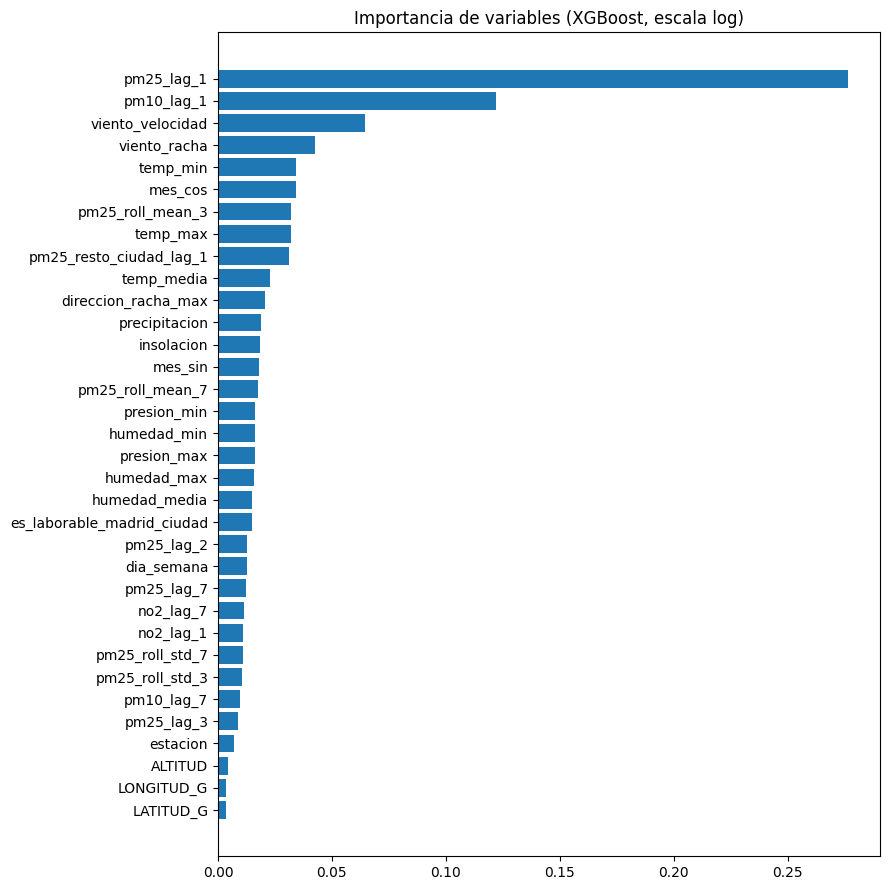

,feature,importancia
21,pm25_lag_1,0.276659
32,pm10_lag_1,0.122087
10,viento_velocidad,0.064638
11,viento_racha,0.042676
1,temp_min,0.034430
16,mes_cos,0.034223
25,pm25_roll_mean_3,0.032154
2,temp_max,0.031996
29,pm25_resto_ciudad_lag_1,0.031333
0,temp_media,0.022765


In [29]:
# ============================================================
# REENTRENAR CON MEJOR CONFIGURACIÓN SOBRE TRAIN, PARA INSPECCIÓN
# ============================================================

modelo_val = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=mejor_n_estimators,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    enable_categorical=True,
    **{k: (int(v) if k == "max_depth" else v) for k, v in mejores_params.items()},
)

modelo_val.fit(X_train, y_train)

importancias = pd.DataFrame({
    "feature": FEATURES,
    "importancia": modelo_val.feature_importances_,
}).sort_values("importancia", ascending=False)

plt.figure(figsize=(9, 9))
plt.barh(importancias["feature"][::-1], importancias["importancia"][::-1])
plt.title("Importancia de variables (XGBoost, escala log)")
plt.tight_layout()
plt.show()

display(importancias)


## 10. Entrenamiento y evaluación final (test 2024)

Se reentrena con 2020–2023 (train + validación) usando la configuración ganadora, y se evalúa una única vez sobre 2024.


In [30]:
# ============================================================
# REENTRENAMIENTO FINAL: TRAIN + VALIDACIÓN (2020-2023)
# ============================================================

train_final_mask = df_modelo["fecha"] < "2024-01-01"

X_train_final = X.loc[train_final_mask]
y_train_final = y.loc[train_final_mask]

modelo_final = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=mejor_n_estimators,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    enable_categorical=True,
    **{k: (int(v) if k == "max_depth" else v) for k, v in mejores_params.items()},
)

modelo_final.fit(X_train_final, y_train_final)

print("Modelo final entrenado correctamente.")
print("Periodo de entrenamiento:",
      df_modelo.loc[train_final_mask, "fecha"].min(), "→",
      df_modelo.loc[train_final_mask, "fecha"].max())


Modelo final entrenado correctamente.
Periodo de entrenamiento: 2020-01-08 00:00:00 → 2023-12-31 00:00:00


In [31]:
# ============================================================
# EVALUACIÓN FINAL SOBRE TEST 2024 (deshaciendo log1p)
# ============================================================

pred_test_log = modelo_final.predict(X_test)
pred_test = np.expm1(pred_test_log)

mae_test = mean_absolute_error(y_test_original, pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test_original, pred_test))
r2_test = r2_score(y_test_original, pred_test)

print("XGBOOST FINAL (PM2.5, escala log) - TEST 2024")
print("-----------------------------------------------")
print(f"MAE:  {mae_test:.3f} µg/m³")
print(f"RMSE: {rmse_test:.3f} µg/m³")
print(f"R²:   {r2_test:.3f}")


XGBOOST FINAL (PM2.5, escala log) - TEST 2024
-----------------------------------------------
MAE:  2.224 µg/m³
RMSE: 3.293 µg/m³
R²:   0.618


In [32]:
# ============================================================
# COMPARACIÓN FINAL: BASELINES vs XGBOOST
# ============================================================

comparacion_final = pd.concat([
    baselines,
    pd.DataFrame([{
        "modelo": "XGBoost (log-target, propio)",
        "MAE": mae_test, "RMSE": rmse_test, "R2": r2_test,
    }])
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

display(comparacion_final)

mejor_baseline_mae = baselines["MAE"].min()
mejora = (mejor_baseline_mae - mae_test) / mejor_baseline_mae * 100
print(f"\nReducción de MAE frente al mejor baseline: {mejora:.2f}%")


,modelo,MAE,RMSE,R2
0,"XGBoost (log-target, propio)",2.224006,3.292532,0.617751
1,Persistencia (lag 1),2.944384,4.343079,0.334908
2,Media móvil 7 días,3.763513,5.160767,0.060894



Reducción de MAE frente al mejor baseline: 24.47%


## 11. Análisis de errores


In [33]:
# ============================================================
# ERROR POR RANGO DE CONCENTRACIÓN
# ============================================================

evaluacion = df_modelo.loc[test_mask, ["fecha", "estacion", "pm25"]].copy()
evaluacion["prediccion"] = pred_test
evaluacion["error"] = evaluacion["pm25"] - evaluacion["prediccion"]
evaluacion["error_absoluto"] = evaluacion["error"].abs()

evaluacion["rango_pm25"] = pd.cut(
    evaluacion["pm25"],
    bins=[0, 5, 10, 15, 25, 50, np.inf],
    labels=["0-5", "5-10", "10-15", "15-25", "25-50", ">50"],
    include_lowest=True,
)

error_por_rango = evaluacion.groupby("rango_pm25", observed=True).agg(
    n=("pm25", "size"),
    pm25_real_medio=("pm25", "mean"),
    MAE=("error_absoluto", "mean"),
)

display(error_por_rango)


,n,pm25_real_medio,MAE
rango_pm25,,,
0-5,823,3.426947,1.478276
5-10,1131,7.251890,1.750969
10-15,629,12.087887,2.266419
15-25,311,18.553277,4.809821
25-50,34,28.651786,11.573229


In [34]:
# ============================================================
# ¿SIGUE FALLANDO EN EL EPISODIO DE CALIMA?
# ============================================================

if dia_pico in evaluacion["fecha"].values:
    print(evaluacion[evaluacion["fecha"] == dia_pico])
else:
    print(f"El episodio de calima ({dia_pico.date()}) no está en el conjunto de test 2024;")
    print("se revisan aquí los peores errores absolutos del test para comprobar si hay eventos similares:")
    display(evaluacion.nlargest(10, "error_absoluto"))


El episodio de calima (2022-03-15) no está en el conjunto de test 2024;
se revisan aquí los peores errores absolutos del test para comprobar si hay eventos similares:


,fecha,estacion,pm25,prediccion,error,error_absoluto,rango_pm25
12533,2024-06-08,56,39.416667,12.811603,26.605064,26.605064,25-50
9013,2024-10-06,48,33.458333,9.299346,24.158987,24.158987,25-50
5373,2024-10-06,38,28.708333,5.826086,22.882247,22.882247,25-50
1733,2024-10-06,8,29.958333,10.024436,19.933897,19.933897,25-50
5398,2024-10-31,38,37.750000,18.623339,19.126661,19.126661,25-50
9038,2024-10-31,48,36.125000,17.494547,18.630453,18.630453,25-50
10833,2024-10-06,50,23.791667,5.607631,18.184035,18.184035,15-25
5397,2024-10-30,38,21.916667,5.209596,16.707071,16.707071,15-25
10858,2024-10-31,50,32.833333,16.487778,16.345556,16.345556,25-50
3553,2024-10-06,24,19.833333,4.091537,15.741796,15.741796,15-25


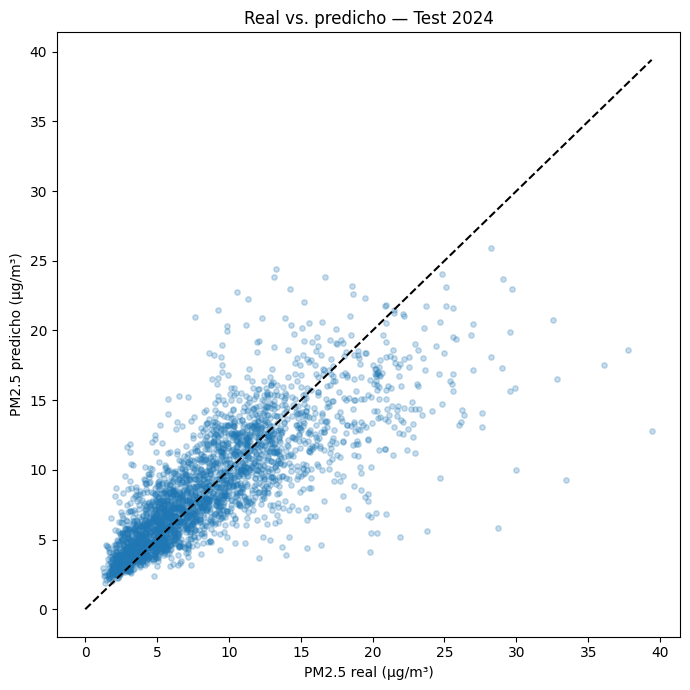

In [35]:
# ============================================================
# VALOR REAL VS PREDICCIÓN
# ============================================================

plt.figure(figsize=(7, 7))
plt.scatter(evaluacion["pm25"], evaluacion["prediccion"], alpha=0.25, s=15)
lim = [0, max(evaluacion["pm25"].max(), evaluacion["prediccion"].max())]
plt.plot(lim, lim, linestyle="--", color="black")
plt.xlabel("PM2.5 real (µg/m³)")
plt.ylabel("PM2.5 predicho (µg/m³)")
plt.title("Real vs. predicho — Test 2024")
plt.tight_layout()
plt.show()


## 12. Interpretabilidad con SHAP


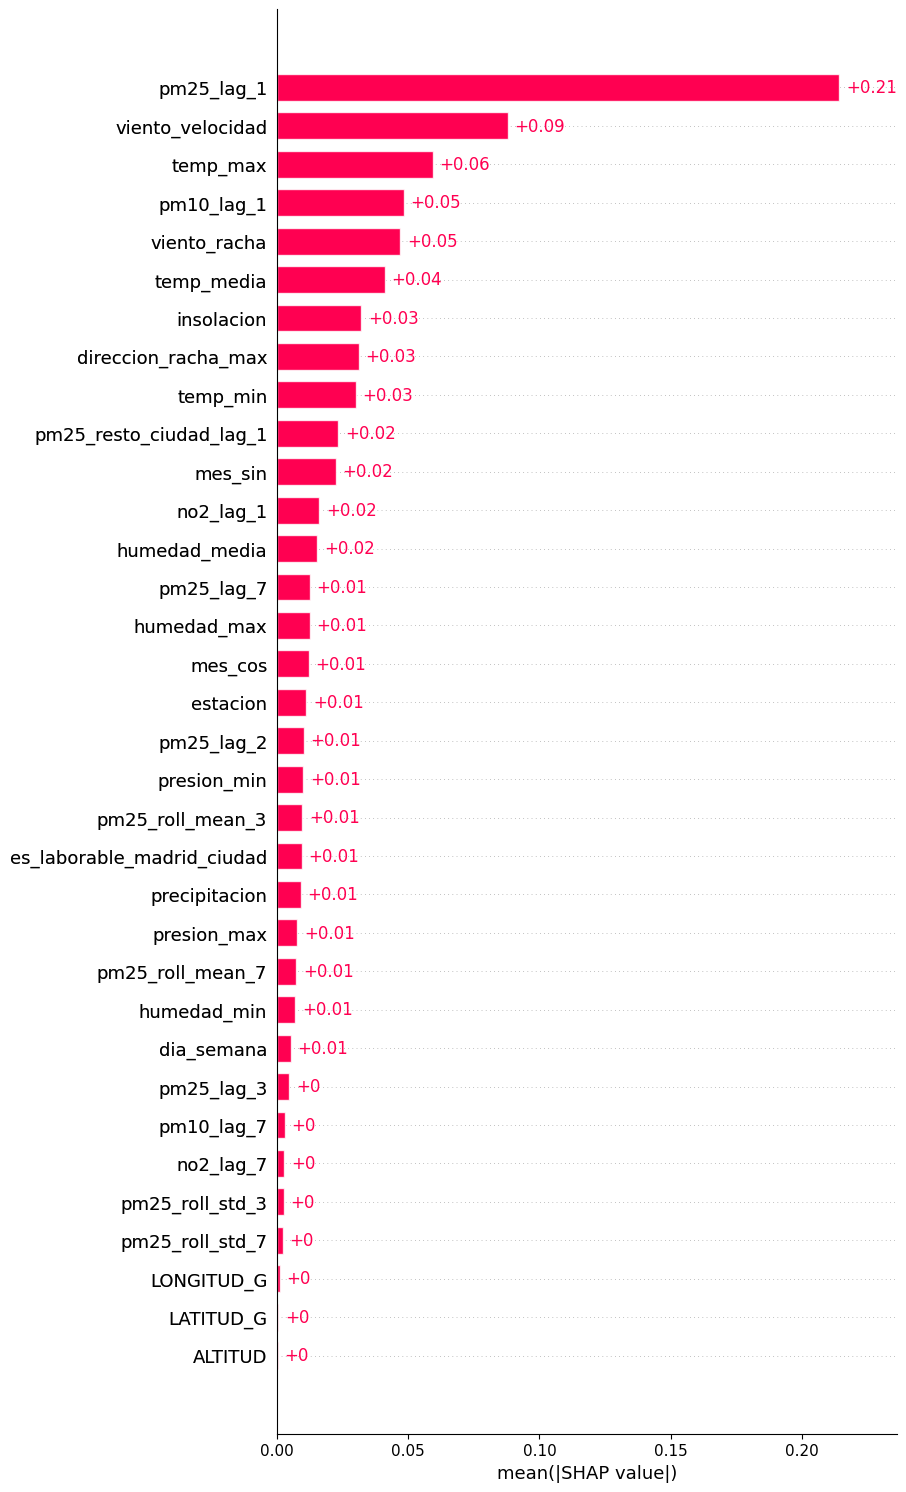

In [36]:
import shap

explainer = shap.TreeExplainer(modelo_final)
shap_values = explainer(X_test)

shap.plots.bar(shap_values, max_display=len(FEATURES))


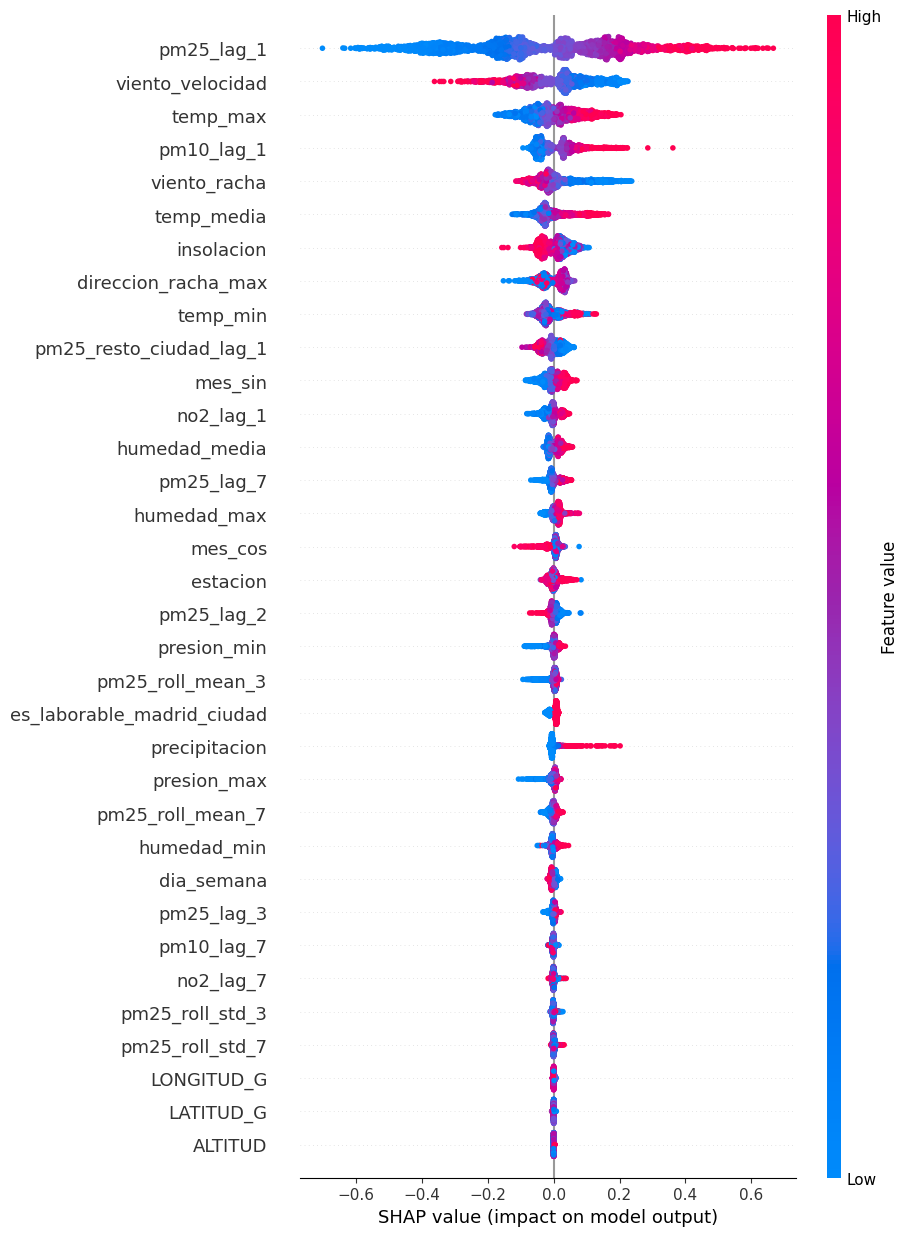

In [37]:
shap.plots.beeswarm(shap_values, max_display=len(FEATURES))


## 13. Guardado del modelo


In [38]:
# ============================================================
# GUARDAR MODELO, FEATURES Y NOTA SOBRE LA TRANSFORMACIÓN LOG
# ============================================================

import joblib

MODEL_PATH = ROOT / "models" / "xgboost_pm25_propio_final.joblib"
FEATURES_PATH = ROOT / "models" / "features_pm25_propio_final.joblib"

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(modelo_final, MODEL_PATH)
joblib.dump({
    "features": FEATURES,
    "target_transform": "log1p",
    "inverse_transform": "expm1",
}, FEATURES_PATH)

print("Modelo guardado:", MODEL_PATH)
print("Metadatos guardados:", FEATURES_PATH)
print("\nRECORDATORIO: las predicciones del modelo están en escala log1p.")
print("Aplicar np.expm1() al resultado de .predict() para obtener µg/m³.")


Modelo guardado: /home/claude/TFM/models/xgboost_pm25_propio_final.joblib
Metadatos guardados: /home/claude/TFM/models/features_pm25_propio_final.joblib

RECORDATORIO: las predicciones del modelo están en escala log1p.
Aplicar np.expm1() al resultado de .predict() para obtener µg/m³.


## 14. Conclusiones y limitaciones

**Resultado final (test 2024, escala original en µg/m³):**

| Modelo | MAE | RMSE | R² |
|---|---|---|---|
| **XGBoost (propio)** | **2.22** | **3.29** | **0.62** |
| Baseline: persistencia (ayer = hoy) | 2.94 | 4.34 | 0.33 |
| Baseline: media móvil 7 días | 3.76 | 5.16 | 0.06 |

El modelo mejora un **24.5%** el MAE frente al mejor baseline (persistencia) — la mejor cifra obtenida hasta ahora entre las distintas versiones del notebook, superando incluso a la versión que usaba promedio ciudad para NO2/PM10.

**Variables con mayor peso (importancia del modelo):**

1. `pm25_lag_1` (concentración del día anterior) — domina claramente.
2. `pm10_lag_1` **de la propia estación** — su importancia sube de forma notable frente a la versión con promedio ciudad (de ≈0.10 a ≈0.12), confirmando que usar el valor real de cada estación, en vez de un promedio diluido, aporta señal más útil.
3. `viento_velocidad` y `viento_racha`.
4. `temp_min`, `mes_cos`, `pm25_roll_mean_3` y el lag espacial `pm25_resto_ciudad_lag_1` completan el top 8.

Las variables espaciales fijas (`LATITUD_G`, `LONGITUD_G`, `ALTITUD`) siguen entre las de menor importancia. `no2_lag_1`/`no2_lag_7` (ahora también propios de cada estación) mantienen un peso moderado, similar al de la versión anterior.

**Error por rango de concentración:**

El error sigue creciendo con el nivel de contaminación: MAE ≈ 1.5 µg/m³ en niveles bajos (0-5) frente a MAE ≈ 11.6 µg/m³ en niveles altos (25-50) — ligeramente mejor que las versiones anteriores en el tramo más extremo.

**Limitación conocida:** el modelo sigue sin tener acceso a datos de intrusiones de polvo sahariano (calima) ni a pronósticos meteorológicos de gran escala. Los mayores errores del conjunto de test 2024 se concentran en las mismas fechas ya identificadas anteriormente (8-jun, 6-oct, 30/31-oct), reforzando que se trata de episodios regionales genuinos y no de un artefacto de una versión concreta del pipeline de features.

**Posibles mejoras futuras:** incorporar datos de calidad del aire regional o de previsión de intrusiones de polvo, y evaluar si un modelo específico para condiciones extremas (por ejemplo, un clasificador previo que detecte "día atípico" antes de aplicar la regresión) reduce el error en la cola alta de la distribución.
